In [97]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [98]:
df=pd.read_csv("/content/data_for_preprocessing.csv")

In [99]:
df


,Unnamed: 0,Text,Author
0,0,This study investigates the chemical compositi...,AI
1,1,This study explores the cultural history of oi...,AI
2,2,Isolation of human peripheral blood mononucle...,Human
3,3,Dynamic Bayesian Networks (DBNs) are probabil...,Human
4,4,"Within volleyball, performance analysis is em...",Human
...,...,...,...
6064,6064,Computational models serve as useful compleme...,Human
6065,6065,During transport and storage of drinking wate...,Human
6066,6066,The parameter values of neural networks will ...,Human
6067,6067,Crumb Rubber Modified Asphalt (CRMA) offers a...,Human


In [100]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [101]:
stop_words=set(stopwords.words('english'))
print(stop_words)
lemmatizer=WordNetLemmatizer()

{'how', 'own', 'will', "needn't", 't', "didn't", 'yours', 'hadn', 'having', 'your', 'is', "shan't", 'here', "weren't", 'off', 'itself', 'where', 'too', 'very', 'couldn', 'am', "it'd", 'an', "i'd", "should've", 'mustn', 'that', 'can', "isn't", 'down', "you're", 'doesn', 'have', 'again', 'ain', 'while', 'after', "you'll", 'why', 'if', "he'd", "it's", 'yourselves', 'hasn', 'our', 'you', 'what', 'being', 'now', 'wasn', 'shouldn', 'been', "couldn't", 'between', 'myself', 'yourself', 'did', 'against', 'most', 'my', 'each', "hasn't", 'because', "she'll", 'then', 'she', 've', "we'll", 'all', 'out', "i'll", 'to', 'on', 'don', 'some', 'these', 'about', "she'd", 'needn', 'be', 'this', 'under', 'his', 'y', 'are', 'them', 'had', 'both', 'more', "wasn't", 'just', "that'll", 'so', 're', 'when', 'was', "you've", 'he', 'through', "they're", "hadn't", 'once', 'aren', 'him', 'ours', 'of', 'which', 'himself', 'no', 'the', 'hers', 'same', 'until', 'in', 'than', "mightn't", 'ourselves', 'ma', 'those', 'its'

In [102]:
def process_text(text):
  word_tokens=word_tokenize(text)
  filtered_token=[word for word in word_tokens if word.lower() not in stop_words]
  lemmatized_tokens=[lemmatizer.lemmatize(word.lower()) for word in filtered_token]
  return {
      'Original_Text':text,
      'Word_Tokens':word_tokens,
      'Filtered_Tokens':filtered_token,
      'Lemmatized_Tokens':lemmatized_tokens
  }

In [103]:
result=df['Text'].apply(process_text)
processed_df=pd.DataFrame(result.tolist())
print(processed_df.head())

                                       Original_Text  \
0  This study investigates the chemical compositi...   
1  This study explores the cultural history of oi...   
2   Isolation of human peripheral blood mononucle...   
3   Dynamic Bayesian Networks (DBNs) are probabil...   
4   Within volleyball, performance analysis is em...   

                                         Word_Tokens  \
0  [This, study, investigates, the, chemical, com...   
1  [This, study, explores, the, cultural, history...   
2  [Isolation, of, human, peripheral, blood, mono...   
3  [Dynamic, Bayesian, Networks, (, DBNs, ), are,...   
4  [Within, volleyball, ,, performance, analysis,...   

                                     Filtered_Tokens  \
0  [study, investigates, chemical, composition, t...   
1  [study, explores, cultural, history, oil, wres...   
2  [Isolation, human, peripheral, blood, mononucl...   
3  [Dynamic, Bayesian, Networks, (, DBNs, ), prob...   
4  [Within, volleyball, ,, performance, analys

In [104]:
processed_file_path='processed_dataset.csv'
processed_df.to_csv(processed_file_path,index=False)
print(f'Processed data saved to {processed_file_path}')

Processed data saved to processed_dataset.csv


In [105]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

In [106]:
text_data=[
"This study investigates the chemical composition of thermal springs in Afyonkarahisar, assessing their potential for health tourism.",
"This study explores the cultural history of oil wrestling in Kırkpınar, analyzing its status as an intangible cultural heritage and its modern organization.",
"Isolation of human peripheral blood mononuclear cells (PBMCs) from blood typically involves a density gradient medium during density centrifugation. The problem of increasing red blood cell (RBC) and granulocyte (GRA) contamination during PBMC isolation as the elapsed time after blood collection increases remains unresolved. As a countermeasure against RBC contamination, hemolysis treatment is available; however, these extra steps are laborious, time-consuming, and could introduce artifacts. To overcome this challenge, we developed a novel isolation device, FlowMagic™, which features a proprietary two-layer insert structure designed to prevent RBC and GRA contamination during PBMC isolation from blood. The efficacy of this method was evaluated by isolating PBMCs from donors and analyzing immune cell populations by flow cytometry. Compared to SepMate (median (Q50) = 11.0, interquartile ranges (IQR): 8.8–19.5; p < 0.01) and Lymphoprep methods (Q50 = 9.3, IQR: 6.6–13.5; p < 0.01), FlowMagic™ achieved significantly greater reduction in RBC contamination to below detectable limits (Q50 = 0.0, IQR: 0.0–0.0), with sustained efficacy observed up to 72 hours post-collection. Additionally, the FlowMagic™ method (Q50 = 2.5, IQR: 0.5–3.4, at 48 hours, median = 4.5, IQR: 2.1–10.3, at 72 hours, respectively) significantly reduced GRA contamination compared with the SepMate (Q50 = 12.0, IQR: 7.8–25.5, at 48 hours, Q50 = 27.5, IQR: 12.3–29.0, at 72 hours, respectively; p < 0.01) and Lymphoprep methods (Q50 = 10.5, IQR: 6.9–19.8, at 48 hours, Q50 = 17.5, IQR: 13.3–23.5, at 72 hours, respectively; p < 0.01) at 48 and 72 hours after blood collection. Furthermore, the recovery rates of CD3 + , CD4 + , CD8 + , CD19 + , and CD16/56 + cells in the FlowMagic™-isolated PBMCs (Q50 = 8.6, 5.9, 2.5, 1.3, and 1.9, respectively) were significantly improved compared to those in SepMate- (Q50 = 2.2, 1.5, 0.7, 0.4, and 0.5, respectively; p < 0.01) and Lymphoprep-isolated PBMCs (Q50 = 2.4, 1.5, 0.8, 0.6, and 0.8, respectively; p < 0.01), even at 48 hours after blood collection. These findings suggest that the PBMC isolation method using FlowMagic™ is advantageous in preventing RBC and GRA contamination for research, diagnostic, and clinical applications. ",
"Dynamic Bayesian Networks (DBNs) are probabilistic models with a directional structure employed to model temporal processes. Three approaches to DBN structure learning are constraint-based, score-based, and hybrid. The score criterion determined in the score-based and hybrid approach has a certain effect on structure learning and this study aims to examine their performance by diversifying the score criteria used in DBN structure learning in addition to the scores commonly used in the literature. Thus, the Akaike-based information criteria as Akaike Information Criterion (AIC), Consistent AIC (CAIC), Kullback-Leibler Information Criterion (KIC), AIC4, and the Bayesian-based information criteria as Bayesian Information Criterion (BIC), Adjusted BIC (BICadj), Haughton BIC (HBIC), BICQ were adapted into the DBN structure learning. The obtained results were discussed. ",
"Within volleyball, performance analysis is employed to identify key performance indicators (KPIs) in relation to success. To date, however, despite the growth in performance analysis, there is little appreciation of the assessment, importance and reporting of reliability of individual variables. This study seeks to establish the inter- and intra-reliability of a bespoke notational analysis system designed for assessing volleyball performance, considering complexes, position, skill, type of skill, and skill efficacy. To establish the inter-reliability, two coders analysed 9 matches, randomly selected from a pool of elite international matches. In addition, to establish the intra-reliability, the primary coder re-analysed one match per month over a nine-month data collection period. Cohen’s Kappa (κ) were established for nominal data, whilst the values for skill efficacy were reported as a Weighted Kappa alongside an Inter-Class Correlation (ICC). Kappa and Weighted Kappa values for all data were shown to be above the acceptable thresholds (κ = 0.75, κ = 0.60, respectively). The present study demonstrates that it is plausible for a bespoke volleyball coding system, implementing a wide array of variables, to have high levels of inter- and intra-reliability. Findings highlight that it is possible for such a system to be utilised over a prolonged period of data collection. ",
"INTENT is an evidence-based smoking prevention programme for secondary school pupils in Great Britain (GB) that was recently expanded to include vaping information. Little research has evaluated GB-specific youth vaping prevention materials. This study assesses teachers’ experiences of delivering INTENT’s vaping prevention materials in England and Scotland. Teachers who delivered INTENT in England/Scotland (N = 45) were surveyed online in 2024, investigating their i) characteristics, ii) experiences of delivering INTENT, iii) perceived impact of INTENT on their pupils, and iv) perceived levels of smoking and vaping in their school. Teachers frequently reported finding pupils possessing/using vapes (51% at least once a week) and perceiving vaping as a problem (96%) in their school, more than cigarettes (4%, 35%, respectively). Teachers had positive or somewhat positive experiences delivering the INTENT vaping prevention materials (96%), perceived that pupils were engaged either ‘a lot’ or ‘somewhat’ (98%), and felt the materials encouraged pupils to make informed choices about vaping (89%). While most teachers reported a change in vaping harm perceptions after INTENT (82%), misperceptions that vaping is equally/more harmful than smoking remained high (65%). A third of teachers did not perceive a change in pupils’ vaping (35.6%) or smoking (26.7%), or did not know (31.1%, 48.9%, respectively). In conclusion, this study found that INTENT shows potential to improve teachers’ knowledge about vaping and smoking and to challenge vaping harm perceptions, and that experiences with delivery and student engagement were positive. Studies evaluating the impact of INTENT and other school-based interventions on school pupils’ vaping and smoking perceptions and behaviours are required. ",
"Traditional opera is continuously involved in the construction of placeness because of its close connection with local culture, and the flow of the meaning of placeness has become a hot spot of cultural geography research. This study examines the driving factors and mechanisms of constructing placeness in Huangmei Opera from the perspective of structuration theory. It adopts qualitative research and positivist methodology to analyze the mutual influence and constructive relationship between Huangmei Opera and placeness. The results reveal that under the structural adjustment of the cultural system reform, multiple subjects respond to the impact of the structural adjustment through the action practices of place marketing and leisure participation, combined with the elements of placeness that the city itself possesses. The study confirms that Huangmei Opera, with its local characteristics, is a quintessential example of placeness construction and that Huangmei Opera achieves placeness construction through the interplay of structure, action, and place. ",
"This research analyzes how Mughal miniature painting synthesized Persian, Indian, and European visual traditions during the 16th-18th centuries. Through detailed formal analysis of specific manuscripts, we demonstrate how artistic hybridity served imperial self-fashioning and cross-cultural diplomacy.",
"This study examines the dialectology of the Black Sea region, focusing on the phonetic characteristics that distinguish it from standard Turkish.",
"Understanding dream formation is scientifically difficult. We used high-density EEG and natural language processing to decode the visual content of dreams during REM sleep. By training a decoder on waking visual imagery, we reconstructed rough video approximations of dream content that correlated with the subjects' verbal reports upon awakening, opening a window into the sleeping mind.",
"AI for history. We used computer vision to piece together fragments of the ""Cairo Genizah"" manuscripts. The AI matched handwriting styles and paper fiber patterns across thousands of fragments. It successfully reconstructed lost texts from the 11th century, revolutionizing the study of medieval history.",
]

In [107]:
vectorizer=CountVectorizer()
bow_matrix=vectorizer.fit_transform(text_data)
bow_df=pd.DataFrame(bow_matrix.toarray(),columns=vectorizer.get_feature_names_out())
print("Bag of Words Representation:")
print(bow_df)
bow_df.to_csv("bag_of_words.csv",index=False)
print("\nBag of Words Saved as 'bag_of_words.csv'.")

Bag of Words Representation:
    01  10  11  11th  12  13  16th  17  18th  19  ...  which  while  whilst  \
0    0   0   0     0   0   0     0   0     0   0  ...      0      0       0   
1    0   0   0     0   0   0     0   0     0   0  ...      0      0       0   
2    6   2   1     0   2   2     0   1     0   2  ...      1      0       0   
3    0   0   0     0   0   0     0   0     0   0  ...      0      0       0   
4    0   0   0     0   0   0     0   0     0   0  ...      0      0       1   
5    0   0   0     0   0   0     0   0     0   0  ...      0      1       0   
6    0   0   0     0   0   0     0   0     0   0  ...      0      0       0   
7    0   0   0     0   0   0     1   0     1   0  ...      0      0       0   
8    0   0   0     0   0   0     0   0     0   0  ...      0      0       0   
9    0   0   0     0   0   0     0   0     0   0  ...      0      0       0   
10   0   0   0     1   0   0     0   0     0   0  ...      0      0       0   

    who  wide  window 

In [108]:
import pandas as pd
import nltk
from nltk.stem import WordNetLemmatizer,PorterStemmer
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [109]:
file_path="/content/data_for_preprocessing.csv"
data=pd.read_csv(file_path)

In [110]:
lemmatizer=WordNetLemmatizer()
stemmer=PorterStemmer()


In [111]:
def lemmatize_text(Text):
    tokens=word_tokenize(str(Text))
    return ' '.join([lemmatizer.lemmatize(word)for word in tokens])


In [112]:
def stem_text(Text):
  tokens=word_tokenize(str(Text))
  return ' '.join([stemmer.stem(word)for word in tokens])

In [113]:
data['lemmatized_text']=data['Text'].apply(lemmatize_text)
data['stemmed_text']=data['Text'].apply(stem_text)

In [114]:
output_path="lemmatiation_vs_stemming.csv"
data.to_csv(output_path,index=False)

In [115]:
print(data[['Text','lemmatized_text','stemmed_text']])
print(f'Comparison dataset saved to {output_path}')

                                                   Text  \
0     This study investigates the chemical compositi...   
1     This study explores the cultural history of oi...   
2      Isolation of human peripheral blood mononucle...   
3      Dynamic Bayesian Networks (DBNs) are probabil...   
4      Within volleyball, performance analysis is em...   
...                                                 ...   
6064   Computational models serve as useful compleme...   
6065   During transport and storage of drinking wate...   
6066   The parameter values of neural networks will ...   
6067   Crumb Rubber Modified Asphalt (CRMA) offers a...   
6068  Generative AI for video is computationally exp...   

                                        lemmatized_text  \
0     This study investigates the chemical compositi...   
1     This study explores the cultural history of oi...   
2     Isolation of human peripheral blood mononuclea...   
3     Dynamic Bayesian Networks ( DBNs ) are probabi...

In [116]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd
file_path="/content/data_for_preprocessing.csv"
text_data=pd.read_csv(file_path)

In [117]:
text_data=" ".join(data['Text'].dropna())

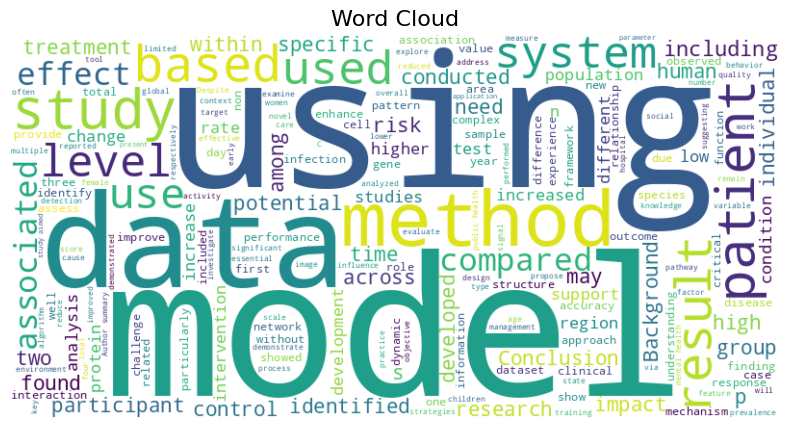

In [118]:
wordcloud=WordCloud(width=800,height=400,background_color='white').generate(text_data)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud',fontsize=16)
plt.show()